In [4]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Load the dataset
file_path = 'customer_shopping_data.csv'  
df = pd.read_csv(file_path)

# Copy to avoid modifying original data
df_cleaned = df.copy()

# Convert invoice_date to datetime, and extract month & hour
df_cleaned['invoice_date'] = pd.to_datetime(df_cleaned['invoice_date'], dayfirst=True, errors='coerce')
df_cleaned['OrderMonth'] = df_cleaned['invoice_date'].dt.month
df_cleaned['OrderHour'] = df_cleaned['invoice_date'].dt.hour

# Calculate a simple "score" as quantity × price
df_cleaned['Score'] = df_cleaned['quantity'] * df_cleaned['price']

# Encode categorical features
encoders = {}
for col in ['gender', 'payment_method', 'category', 'shopping_mall']:
    le = LabelEncoder()
    df_cleaned[col + '_enc'] = le.fit_transform(df_cleaned[col])
    encoders[col] = le 

# Create user-level aggregated behavior features
user_stats = df_cleaned.groupby('customer_id').agg(
    total_orders=('invoice_no', 'nunique'),
    avg_spent=('Score', 'mean'),
    total_spent=('Score', 'sum'),
    unique_categories=('category', 'nunique')
).reset_index()

# Merge user behavior features back into main DataFrame
df_customer_shopping = pd.merge(df_cleaned, user_stats, on='customer_id', how='left')

df_customer_shopping = df_customer_shopping[(df_customer_shopping['quantity'] > 0) & (df_customer_shopping['price'] > 0)]

print("number of rows: ", len(df_customer_shopping))
print(df_customer_shopping.isnull().sum())

df_customer_shopping

number of rows:  99457
invoice_no            0
customer_id           0
gender                0
age                   0
category              0
quantity              0
price                 0
payment_method        0
invoice_date          0
shopping_mall         0
OrderMonth            0
OrderHour             0
Score                 0
gender_enc            0
payment_method_enc    0
category_enc          0
shopping_mall_enc     0
total_orders          0
avg_spent             0
total_spent           0
unique_categories     0
dtype: int64


,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall,...,OrderHour,Score,gender_enc,payment_method_enc,category_enc,shopping_mall_enc,total_orders,avg_spent,total_spent,unique_categories
0,I138884,C241288,Female,28,Clothing,5,1500.40,Credit Card,2022-08-05,Kanyon,...,0,7502.00,0,1,1,4,1,7502.00,7502.00,1
1,I317333,C111565,Male,21,Shoes,3,1800.51,Debit Card,2021-12-12,Forum Istanbul,...,0,5401.53,1,2,4,2,1,5401.53,5401.53,1
2,I127801,C266599,Male,20,Clothing,1,300.08,Cash,2021-11-09,Metrocity,...,0,300.08,1,0,1,6,1,300.08,300.08,1
3,I173702,C988172,Female,66,Shoes,5,3000.85,Credit Card,2021-05-16,Metropol AVM,...,0,15004.25,0,1,4,7,1,15004.25,15004.25,1
4,I337046,C189076,Female,53,Books,4,60.60,Cash,2021-10-24,Kanyon,...,0,242.40,0,0,0,4,1,242.40,242.40,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99452,I219422,C441542,Female,45,Souvenir,5,58.65,Credit Card,2022-09-21,Kanyon,...,0,293.25,0,1,5,4,1,293.25,293.25,1
99453,I325143,C569580,Male,27,Food & Beverage,2,10.46,Cash,2021-09-22,Forum Istanbul,...,0,20.92,1,0,3,2,1,20.92,20.92,1
99454,I824010,C103292,Male,63,Food & Beverage,2,10.46,Debit Card,2021-03-28,Metrocity,...,0,20.92,1,2,3,6,1,20.92,20.92,1
99455,I702964,C800631,Male,56,Technology,4,4200.00,Cash,2021-03-16,Istinye Park,...,0,16800.00,1,0,6,3,1,16800.00,16800.00,1


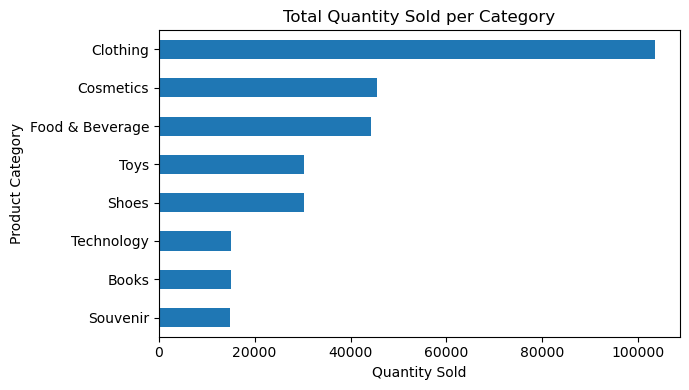

In [10]:
import matplotlib.pyplot as plt
category_sales = df_customer_shopping.groupby('category')['quantity'].sum().sort_values()

plt.figure(figsize=(7, 4))
category_sales.plot(kind='barh')
plt.title('Total Quantity Sold per Category')
plt.xlabel('Quantity Sold')
plt.ylabel('Product Category')
plt.tight_layout()
plt.show()

In [2]:
import pandas as pd
import math

# 1. Compute score as quantity × price
df_customer_shopping["Score"] = df_customer_shopping["quantity"] * df_customer_shopping["price"]

# 2. Manual Label Encoding: convert categorical variables to integers
def manual_label_encoding(series):
    unique_vals = sorted(series.dropna().unique())
    val_to_int = {val: i for i, val in enumerate(unique_vals)}
    return series.map(val_to_int), val_to_int

# Encode the four categorical features manually
label_maps = {}  # Store mappings for reference
for col in ['gender', 'payment_method', 'category', 'shopping_mall']:
    df_customer_shopping[col + '_enc'], label_maps[col] = manual_label_encoding(df_customer_shopping[col])

# 3. Generate user-level aggregated features
user_stats = df_customer_shopping.groupby('customer_id').agg(
    total_orders=('invoice_no', 'nunique'),
    avg_spent=('Score', 'mean'),
    total_spent=('Score', 'sum'),
    unique_categories=('category', 'nunique')
).reset_index()

# Merge aggregated features back to the original data
df_ready = pd.merge(df_customer_shopping, user_stats, on='customer_id', how='left')

# 4. Create a user-item score matrix using 'category' as item
user_item_matrix = df_ready.pivot_table(
    index='customer_id',
    columns='category',
    values='Score',
    aggfunc='sum',
    fill_value=0
)

# 5. Manually compute item-item similarity using Pearson correlation
def manual_pearson_corr(df):
    item_names = df.columns
    similarity = pd.DataFrame(index=item_names, columns=item_names, dtype='float')
    
    for i in item_names:
        for j in item_names:
            xi = df[i]
            xj = df[j]
            mean_i, mean_j = xi.mean(), xj.mean()
            numerator = ((xi - mean_i) * (xj - mean_j)).sum()
            denominator = (((xi - mean_i) ** 2).sum() * ((xj - mean_j) ** 2).sum()) ** 0.5
            similarity.loc[i, j] = numerator / denominator if denominator != 0 else 0
    return similarity

item_similarity = manual_pearson_corr(user_item_matrix)

# 6. Predict user-item scores based on item-item similarity
cf_score_matrix = user_item_matrix.dot(item_similarity).div(item_similarity.sum(axis=0), axis=1)

# 7. Convert the prediction matrix to long format
cf_score_long = cf_score_matrix.stack().reset_index()
cf_score_long.columns = ['customer_id', 'category', 'cf_score']

# 8. Post-processing: shift, log transform, and normalize scores

# 8.1 Shift all scores to ensure positivity
min_score = cf_score_long["cf_score"].min()
cf_score_long["cf_score_shifted"] = cf_score_long["cf_score"] - min_score + 1e-6

# 8.2 Apply log(1 + x) transformation manually
cf_score_long["cf_score_log"] = cf_score_long["cf_score_shifted"].apply(lambda x: math.log(1 + x))

# 8.3 Normalize scores to the [0, 1] range using manual Min-Max scaling
log_min = cf_score_long["cf_score_log"].min()
log_max = cf_score_long["cf_score_log"].max()
cf_score_long["cf_score_scaled"] = cf_score_long["cf_score_log"].apply(
    lambda x: (x - log_min) / (log_max - log_min) if log_max > log_min else 0.0
)

# 9. Save the final results to CSV for use in the MLP model
cf_score_long.to_csv("cf_scores_for_mlp.csv", index=False)